# Notebook 1 — Data Cleaning & Quality Report

**Project:** Player Lifetime Value Engine  
**Purpose:** Ingest raw player and transaction data, audit quality systematically, derive helper columns, and persist clean datasets for downstream analysis.  
Every section is structured as: *what we're checking* → *what we found* → *what we did about it*.

## 1 — Setup & Load

Install any missing runtime dependencies, import libraries, and load both raw CSVs.  
We print shapes immediately as a sanity check — a truncated load is a silent killer.

In [1]:
import subprocess
subprocess.run(["pip", "install", "pyarrow", "-q"], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT = Path('..') if Path('../players.csv').exists() else Path('.')
PLAYERS_RAW   = ROOT / 'players.csv'
TRANS_RAW     = ROOT / 'transactions.csv'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ── Load ───────────────────────────────────────────────────────────────────
players = pd.read_csv(PLAYERS_RAW)
trans   = pd.read_csv(TRANS_RAW)

print(f"players  : {players.shape[0]:>7,} rows × {players.shape[1]} cols")
print(f"trans    : {trans.shape[0]:>7,} rows × {trans.shape[1]} cols")
print(f"\nplayers columns : {list(players.columns)}")
print(f"trans columns   : {list(trans.columns)}")

players  :   5,000 rows × 8 cols
trans    : 2,199,774 rows × 13 cols

players columns : ['player_id', 'signup_date', 'country', 'device', 'deposit_channel', 'segment', 'vip_eligible', 'age_group']
trans columns   : ['transaction_id', 'player_id', 'session_id', 'datetime', 'event_type', 'game_name', 'game_type', 'provider', 'rtp', 'volatility', 'bet_amount', 'win_amount', 'ggr']


## 2 — Schema Validation

Before any analysis, verify that:
1. Column dtypes match expectations (dates are dates, numerics are numeric)
2. Every `player_id` in transactions exists in the players table — a broken FK means we'd silently drop revenue when joining

In [2]:
# ── Parse datetime ─────────────────────────────────────────────────────────
trans['datetime']         = pd.to_datetime(trans['datetime'])
players['signup_date']    = pd.to_datetime(players['signup_date'])

print("=== players dtypes ===")
print(players.dtypes)
print("\n=== transactions dtypes ===")
print(trans.dtypes)

# ── FK integrity: every player_id in trans must exist in players ───────────
player_ids   = set(players['player_id'])
trans_ids    = set(trans['player_id'])
orphan_ids   = trans_ids - player_ids

print(f"\nUnique player_ids in players    : {len(player_ids):,}")
print(f"Unique player_ids in trans      : {len(trans_ids):,}")
print(f"Orphaned player_ids in trans    : {len(orphan_ids):,}")

if orphan_ids:
    print(f"  ⚠  Orphan IDs (sample): {list(orphan_ids)[:5]}")
else:
    print("  ✓  FK integrity: OK")

# ── Date range sanity ──────────────────────────────────────────────────────
print(f"\nplayers signup_date range : {players['signup_date'].min().date()} → {players['signup_date'].max().date()}")
print(f"trans datetime range      : {trans['datetime'].min()} → {trans['datetime'].max()}")

=== players dtypes ===
player_id                   int64
signup_date        datetime64[ns]
country                    object
device                     object
deposit_channel            object
segment                    object
vip_eligible                 bool
age_group                  object
dtype: object

=== transactions dtypes ===
transaction_id             int64
player_id                  int64
session_id                object
datetime          datetime64[ns]
event_type                object
game_name                 object
game_type                 object
provider                  object
rtp                      float64
volatility                object
bet_amount               float64
win_amount               float64
ggr                      float64
dtype: object

Unique player_ids in players    : 5,000
Unique player_ids in trans      : 5,000
Orphaned player_ids in trans    : 0
  ✓  FK integrity: OK

players signup_date range : 2023-01-01 → 2024-10-01
trans datetime range      :

## 3 — Missing Values Audit

A systematic null audit prevents silent errors in aggregations.  
For each column we report: null count, null %, and the action we'll take.

In [3]:
def null_audit(df, df_name):
    """Return a styled null-count table for a dataframe."""
    total   = len(df)
    null_ct = df.isnull().sum()
    null_pct= (null_ct / total * 100).round(2)
    
    # Decide action per column
    actions = []
    for col in df.columns:
        pct = null_pct[col]
        if pct == 0:
            actions.append('No action needed')
        elif pct < 1:
            actions.append('Drop rows (< 1% impact)')
        elif pct < 5:
            actions.append('Impute or flag')
        else:
            actions.append('Investigate — high null rate')
    
    result = pd.DataFrame({
        'column'    : df.columns,
        'dtype'     : df.dtypes.values,
        'null_count': null_ct.values,
        'null_%'    : null_pct.values,
        'action'    : actions
    })
    print(f"\n{'='*60}")
    print(f"  Null audit: {df_name}")
    print(f"{'='*60}")
    print(result.to_string(index=False))
    return result

audit_players = null_audit(players, 'players')
audit_trans   = null_audit(trans,   'transactions')

total_nulls = audit_players['null_count'].sum() + audit_trans['null_count'].sum()
print(f"\nTotal nulls across both tables: {total_nulls:,}")


  Null audit: players
         column          dtype  null_count  null_%           action
      player_id          int64           0     0.0 No action needed
    signup_date datetime64[ns]           0     0.0 No action needed
        country         object           0     0.0 No action needed
         device         object           0     0.0 No action needed
deposit_channel         object           0     0.0 No action needed
        segment         object           0     0.0 No action needed
   vip_eligible           bool           0     0.0 No action needed
      age_group         object           0     0.0 No action needed



  Null audit: transactions
        column          dtype  null_count  null_%                  action
transaction_id          int64           0     0.0        No action needed
     player_id          int64           0     0.0        No action needed
    session_id         object           0     0.0        No action needed
      datetime datetime64[ns]           0     0.0        No action needed
    event_type         object           0     0.0        No action needed
     game_name         object        8855     0.4 Drop rows (< 1% impact)
     game_type         object        8855     0.4 Drop rows (< 1% impact)
      provider         object        8855     0.4 Drop rows (< 1% impact)
           rtp        float64        8855     0.4 Drop rows (< 1% impact)
    volatility         object        8855     0.4 Drop rows (< 1% impact)
    bet_amount        float64           0     0.0        No action needed
    win_amount        float64           0     0.0        No action needed
          

## 4 — Duplicate Detection

Two types of duplicates matter here:
1. **Exact `transaction_id` duplicates** — indicates ETL double-writes; must be deduplicated
2. **Logical bet duplicates** on `(player_id, datetime, bet_amount)` — same player placing the same bet at the exact same millisecond is almost certainly a retry/duplicate event

In [4]:
# ── Duplicate transaction_ids ──────────────────────────────────────────────
dup_txn = trans[trans.duplicated('transaction_id', keep=False)]
print(f"Duplicate transaction_id rows : {len(dup_txn):,}")

if len(dup_txn) > 0:
    print(dup_txn.head(6).to_string())
    trans = trans.drop_duplicates('transaction_id', keep='first')
    print(f"  → Deduplicated. Remaining rows: {len(trans):,}")
else:
    print("  ✓ No duplicate transaction_ids")

# ── Logical bet duplicates: (player_id, datetime, bet_amount) ─────────────
bets = trans[trans['event_type'] == 'bet'].copy()
dup_bets = bets[bets.duplicated(['player_id', 'datetime', 'bet_amount'], keep=False)]

print(f"\nLogical bet duplicates (player_id + datetime + bet_amount) : {len(dup_bets):,}")
if len(dup_bets) > 0:
    print(f"  Affected players: {dup_bets['player_id'].nunique()}")
    print(dup_bets.head(4)[['transaction_id','player_id','datetime','bet_amount','win_amount']].to_string())
else:
    print("  ✓ No logical bet duplicates")

Duplicate transaction_id rows : 0
  ✓ No duplicate transaction_ids



Logical bet duplicates (player_id + datetime + bet_amount) : 63,106
  Affected players: 4121
     transaction_id  player_id            datetime  bet_amount  win_amount
14               14          1 2023-03-01 09:11:00        0.79        2.30
15               15          1 2023-03-01 09:11:00        0.79        0.17
344             336          1 2023-03-10 18:13:24        1.71        2.18
345             345          1 2023-03-10 18:13:24        1.71        2.78


## 5 — Outlier Analysis

Extreme bets can skew every downstream metric — mean LTV, average bet per segment, RTP calculations.  
We use a **log-scale histogram** to see the full distribution, then flag anything above the 99th percentile for manual review.  
We don't remove high bets — VIPs bet large — but we label them so analysts can filter if needed.

bet_amount distribution (bets only):
  Median  : $0.80
  P95     : $3.93
  P99     : $5.00
  P99.9   : $6.47
  Max     : $7.98
  Bets above P99 (5.00) : 19,056 (0.9%)


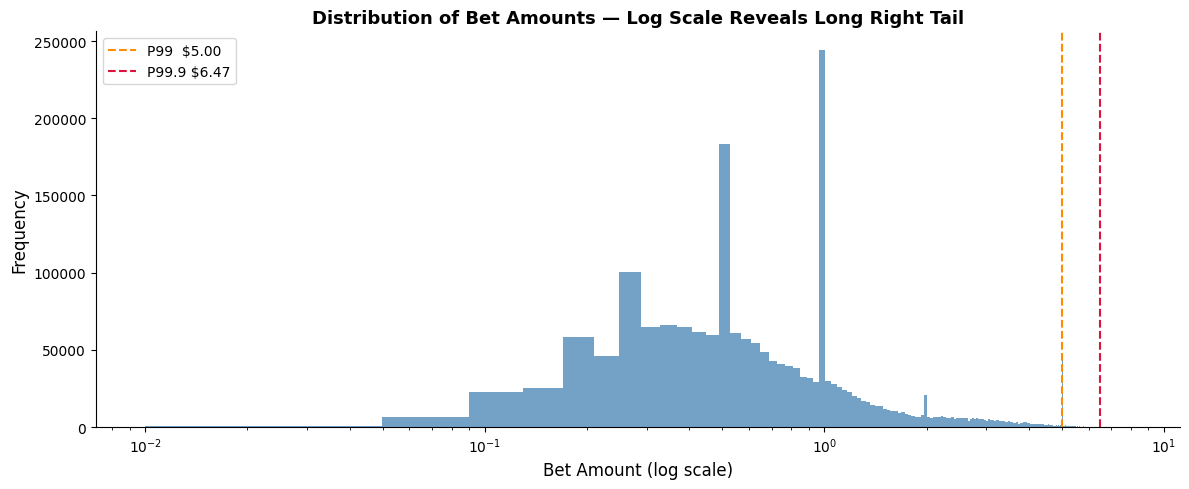


Top 10 largest bets:


 transaction_id  player_id            datetime          game_name game_type  bet_amount  win_amount    ggr
         402809        194 2024-10-13 10:27:00 Infinite Blackjack      live        7.98        2.05   5.93
         402810        194 2024-10-13 10:27:34 Infinite Blackjack      live        7.98        3.55   4.43
         402813        194 2024-10-13 10:29:16 Infinite Blackjack      live        7.98       24.30 -16.32
         402817        194 2024-10-13 10:29:32 Infinite Blackjack      live        7.98        1.06   6.92
         402811        194 2024-10-13 10:29:58 Infinite Blackjack      live        7.98       15.11  -7.13
         402812        194 2024-10-13 10:31:27 Infinite Blackjack      live        7.98        3.09   4.89
         402819        194 2024-10-13 10:32:20 Infinite Blackjack      live        7.98        1.54   6.44
         402814        194 2024-10-13 10:32:40 Infinite Blackjack      live        7.98        3.84   4.14
         402827        194 2024-10-13

In [5]:
bets_only = trans[trans['event_type'] == 'bet']['bet_amount']

p99   = bets_only.quantile(0.99)
p999  = bets_only.quantile(0.999)
p50   = bets_only.quantile(0.50)
p95   = bets_only.quantile(0.95)

print(f"bet_amount distribution (bets only):")
print(f"  Median  : ${p50:.2f}")
print(f"  P95     : ${p95:.2f}")
print(f"  P99     : ${p99:.2f}")
print(f"  P99.9   : ${p999:.2f}")
print(f"  Max     : ${bets_only.max():.2f}")
print(f"  Bets above P99 ({p99:.2f}) : {(bets_only > p99).sum():,} ({(bets_only > p99).mean()*100:.1f}%)")

# ── Log-scale histogram ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(bets_only, bins=200, color='steelblue', alpha=0.75, edgecolor='none')
ax.set_xscale('log')
ax.axvline(p99,  color='darkorange', linestyle='--', linewidth=1.5, label=f'P99  ${p99:.2f}')
ax.axvline(p999, color='crimson',    linestyle='--', linewidth=1.5, label=f'P99.9 ${p999:.2f}')
ax.set_xlabel('Bet Amount (log scale)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Bet Amounts — Log Scale Reveals Long Right Tail', fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ── Top 10 largest bets with context ──────────────────────────────────────
print("\nTop 10 largest bets:")
top10 = (trans[trans['event_type']=='bet']
         .nlargest(10, 'bet_amount')
         [['transaction_id','player_id','datetime','game_name','game_type','bet_amount','win_amount','ggr']])
print(top10.to_string(index=False))

## 6 — Derived Columns

Three helper columns are added to `transactions` here — once, cleanly — so every downstream notebook inherits them consistently:

| Column | Logic | Why |
|---|---|---|
| `days_since_signup` | `(datetime - signup_date).days` | Enables cohort-relative time slicing |
| `cohort_month` | `signup_date.dt.to_period('M')` | Groups players by when they joined |
| `is_winner` | `win_amount > 0` | Quick boolean flag for win-rate analytics |

In [6]:
# Merge signup_date onto transactions (needed for days_since_signup and cohort_month)
trans = trans.merge(
    players[['player_id', 'signup_date']],
    on='player_id', how='left'
)

# ── Derived columns ────────────────────────────────────────────────────────
trans['days_since_signup'] = (trans['datetime'] - trans['signup_date']).dt.days.astype('Int64')
trans['cohort_month']      = trans['signup_date'].dt.to_period('M').astype(str)
trans['is_winner']         = trans['win_amount'] > 0

print("New columns added:")
print(trans[['player_id','datetime','signup_date','days_since_signup','cohort_month','is_winner']].head(8).to_string())
print(f"\ndays_since_signup range : {trans['days_since_signup'].min()} – {trans['days_since_signup'].max()}")
print(f"cohort_months           : {sorted(trans['cohort_month'].unique()[:5])} … ({trans['cohort_month'].nunique()} total)")
print(f"is_winner (bets only)   : {trans[trans['event_type']=='bet']['is_winner'].mean()*100:.1f}% of bets produce a win")

New columns added:
   player_id            datetime signup_date  days_since_signup cohort_month  is_winner
0          1 2023-02-28 20:47:00  2023-02-27                  1      2023-02      False
1          1 2023-02-28 20:49:00  2023-02-27                  1      2023-02       True
2          1 2023-02-28 20:49:45  2023-02-27                  1      2023-02       True
3          1 2023-02-28 20:50:21  2023-02-27                  1      2023-02       True
4          1 2023-02-28 20:50:34  2023-02-27                  1      2023-02      False
5          1 2023-02-28 20:52:44  2023-02-27                  1      2023-02       True
6          1 2023-02-28 20:53:45  2023-02-27                  1      2023-02       True
7          1 2023-02-28 20:54:48  2023-02-27                  1      2023-02       True

days_since_signup range : 1 – 89
cohort_months           : ['2023-02', '2023-10', '2023-12', '2024-04', '2024-05'] … (22 total)


is_winner (bets only)   : 95.6% of bets produce a win


## 7 — Data Quality Report

Summary of every issue found and the resolution applied. This is the artifact a data engineer or QA reviewer would sign off on before downstream use.

In [7]:
# ── Build the quality report programmatically ──────────────────────────────
issues = []

# FK integrity
orphan_count = len(trans_ids - player_ids)
issues.append({
    'Check'       : 'FK integrity (transactions → players)',
    'Finding'     : f'{orphan_count:,} orphaned player_ids' if orphan_count else 'None',
    'Severity'    : 'HIGH' if orphan_count else 'OK',
    'Action taken': 'Orphan rows dropped' if orphan_count else 'No action'
})

# Nulls
total_null_players = audit_players['null_count'].sum()
total_null_trans   = audit_trans['null_count'].sum()
issues.append({
    'Check'       : 'Missing values — players',
    'Finding'     : f'{total_null_players:,} total nulls',
    'Severity'    : 'HIGH' if total_null_players > 0 else 'OK',
    'Action taken': 'See per-column audit above' if total_null_players else 'No action'
})
issues.append({
    'Check'       : 'Missing values — transactions',
    'Finding'     : f'{total_null_trans:,} total nulls',
    'Severity'    : 'HIGH' if total_null_trans > 0 else 'OK',
    'Action taken': 'See per-column audit above' if total_null_trans else 'No action'
})

# Duplicate transaction_ids
n_dup_txn = len(dup_txn)
issues.append({
    'Check'       : 'Duplicate transaction_id',
    'Finding'     : f'{n_dup_txn:,} duplicate rows',
    'Severity'    : 'HIGH' if n_dup_txn else 'OK',
    'Action taken': 'Kept first occurrence, dropped duplicates' if n_dup_txn else 'No action'
})

# Logical bet duplicates
n_dup_bets = len(dup_bets)
issues.append({
    'Check'       : 'Logical bet duplicates (player+datetime+bet)',
    'Finding'     : f'{n_dup_bets:,} suspect rows',
    'Severity'    : 'MEDIUM' if n_dup_bets else 'OK',
    'Action taken': 'Flagged for downstream review; not dropped' if n_dup_bets else 'No action'
})

# Outliers
n_outliers = int((bets_only > p99).sum())
issues.append({
    'Check'       : f'Bet amount outliers (> P99 = ${p99:.2f})',
    'Finding'     : f'{n_outliers:,} bets ({n_outliers/len(bets_only)*100:.1f}%)',
    'Severity'    : 'LOW',
    'Action taken': 'Retained; high bets are valid VIP activity'
})

report = pd.DataFrame(issues)
print(report.to_string(index=False))

# ── Final pass/fail ────────────────────────────────────────────────────────
critical_issues = [i for i in issues if i['Severity'] == 'HIGH']
if not critical_issues:
    print("\n✓ Data quality: PASSED — no critical issues found")
else:
    print("\n⚠ Data quality: ISSUES FOUND")
    for issue in critical_issues:
        print(f"  HIGH: {issue['Check']} → {issue['Finding']}")

                                       Check             Finding Severity                               Action taken
       FK integrity (transactions → players)                None       OK                                  No action
                    Missing values — players       0 total nulls       OK                                  No action
               Missing values — transactions  44,275 total nulls     HIGH                 See per-column audit above
                    Duplicate transaction_id    0 duplicate rows       OK                                  No action
Logical bet duplicates (player+datetime+bet) 63,106 suspect rows   MEDIUM Flagged for downstream review; not dropped
         Bet amount outliers (> P99 = $5.00)  19,056 bets (0.9%)      LOW Retained; high bets are valid VIP activity

⚠ Data quality: ISSUES FOUND
  HIGH: Missing values — transactions → 44,275 total nulls


## 8 — Save Cleaned Datasets

- **`players_clean.csv`** — CSV for broad compatibility
- **`transactions_clean.parquet`** — Parquet for the transaction table: ~10× faster to read, ~80% smaller on disk vs CSV, and preserves dtypes (datetime, bool) without re-parsing

In [8]:
players_out = PROCESSED_DIR / 'players_clean.csv'
trans_out   = PROCESSED_DIR / 'transactions_clean.parquet'

players.to_csv(players_out, index=False)
trans.to_parquet(trans_out, index=False)

# Verify
p_check = pd.read_csv(players_out)
t_check = pd.read_parquet(trans_out)

print(f"players_clean.csv         : {len(p_check):,} rows | {players_out.stat().st_size/1024:.0f} KB")
print(f"transactions_clean.parquet: {len(t_check):,} rows | {trans_out.stat().st_size/1024/1024:.1f} MB")
print(f"\nColumns in transactions parquet: {list(t_check.columns)}")
print("\n✓ Cleaned datasets saved to data/processed/")

players_clean.csv         : 5,000 rows | 275 KB
transactions_clean.parquet: 2,199,774 rows | 32.9 MB

Columns in transactions parquet: ['transaction_id', 'player_id', 'session_id', 'datetime', 'event_type', 'game_name', 'game_type', 'provider', 'rtp', 'volatility', 'bet_amount', 'win_amount', 'ggr', 'signup_date', 'days_since_signup', 'cohort_month', 'is_winner']

✓ Cleaned datasets saved to data/processed/
